# Temperature change in Larnaca, Cyprus

Repeat the Boulder workflow using NOAA daily-average temperature (TAVG), station CY000176090. Start with 1978–2024; inspect monthly coverage before selecting annual means.

Steps: load and check daily observations, aggregate by year, plot static and interactive series, and fit an ordinary least squares trend. Portfolio interpretation will be written after reviewing the results.

In [1]:
%matplotlib inline
import sys
import calendar
import hashlib
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import hvplot.pandas
from sklearn.linear_model import LinearRegression

print(f"Python {sys.version.split()[0]}: {sys.executable}")

Python 3.11.6: /opt/conda/bin/python


## Load the daily observations

Use the saved [NOAA GHCN-Daily snapshot](https://www.ncei.noaa.gov/pub/data/ghcn/daily/all/CY000176090.dly) for Larnaca (CY000176090; 34.8831° N, 33.6331° E). The source URL, retrieval time and checksum are saved in data/cyprus_climate/source.json.

The fixed-width file stores temperature in **tenths of °C**, so divide by 10. This record's TAVG (measurement flag H, source S) averages hourly readings over a UTC day. It differs from Boulder's observation-time TOBS; no Fahrenheit conversion is needed. Treat -9999 and nonblank quality flags as missing. See [NOAA's format and flag definitions](https://www.ncei.noaa.gov/pub/data/ghcn/daily/readme.txt).

Run this notebook from the repository root using the base Python 3.11.6 kernel. The committed snapshot makes the analysis reproducible without downloading a changing source on each run.

In [2]:
data_dir = Path("data/cyprus_climate")
source = json.loads((data_dir / "source.json").read_text())
raw = (data_dir / "CY000176090.dly").read_bytes()
assert hashlib.sha256(raw).hexdigest() == source["sha256"]

records = []
for line in raw.decode("ascii").splitlines():
    assert line[:11] == source["station"]
    if line[17:21] != "TAVG":
        continue
    year, month = int(line[11:15]), int(line[15:17])
    for day in range(1, calendar.monthrange(year, month)[1] + 1):
        start = 21 + (day - 1) * 8
        value = int(line[start:start + 5])
        mflag, qflag, sflag = line[start + 5:start + 8]
        valid = value != -9999 and qflag == " "
        records.append({"date": pd.Timestamp(year, month, day),
                        "temp_c": value / 10 if valid else float("nan"),
                        "measurement_flag": mflag.strip(),
                        "quality_flag": qflag.strip(),
                        "source_flag": sflag.strip()})

daily = pd.DataFrame(records).set_index("date").sort_index()
assert daily.index.is_unique
print("Valid record:", daily.temp_c.first_valid_index().date(),
      "to", daily.temp_c.last_valid_index().date())
daily.loc[daily.temp_c.notna()].head()

Valid record: 1977-01-14 to 2025-08-24


,temp_c,measurement_flag,quality_flag,source_flag
date,,,,
1977-01-14,9.3,H,,S
1977-01-15,8.5,H,,S
1977-01-22,10.3,H,,S
1977-01-23,9.0,H,,S
1977-01-28,10.4,H,,S


In [3]:
# Reindex to calendar days so absent rows also count as missing.
calendar_days = pd.date_range("1978-01-01", "2024-12-31", name="date")
temperature = daily.temp_c.reindex(calendar_days)
print(f"1978–2024: {temperature.count():,} valid days / {len(temperature):,} calendar days")
print(f"Missing days: {temperature.isna().sum()}; coverage: {temperature.notna().mean():.3%}")
print("Flags on valid observations:")
display(daily.loc[temperature.dropna().index,
                  ["measurement_flag", "quality_flag", "source_flag"]].value_counts())
assert temperature.count() == 17150
assert temperature.isna().sum() == 17

1978–2024: 17,150 valid days / 17,167 calendar days
Missing days: 17; coverage: 99.901%
Flags on valid observations:


measurement_flag  quality_flag  source_flag
H                               S              17150
Name: count, dtype: int64

## Check coverage before calculating the trend

Use 1978–2024 as the candidate window. The preceding year is incomplete, and this snapshot ends on August 24, 2025, so neither 1977 nor 2025 enters the annual analysis.

For the main analysis, retain a year only when **every month has at least 90% of its daily temperatures**. This is an explicit analysis choice, intended to limit seasonal bias from missing observations, not an official NOAA completeness standard. Test 80% and 100% thresholds later. No missing days are filled.

As in Boulder, each annual value is the arithmetic mean of the available daily temperatures. Even a nearly complete annual total can hide a concentrated monthly gap, so inspect both annual and monthly coverage.

In [4]:
monthly = temperature.resample("MS").agg(["mean", "count"])
monthly.columns = ["temp_c", "valid_days"]
monthly["expected_days"] = monthly.index.days_in_month
monthly["coverage"] = monthly.valid_days / monthly.expected_days
monthly["missing_days"] = monthly.expected_days - monthly.valid_days

display(monthly.loc[monthly.missing_days > 0,
                    ["valid_days", "expected_days", "missing_days", "coverage"]])

annual = temperature.resample("YS").agg(["mean", "count", "size"])
annual.columns = ["temp_c", "valid_days", "expected_days"]
annual["coverage_pct"] = 100 * annual.valid_days / annual.expected_days
annual["min_month_coverage"] = monthly.coverage.resample("YS").min()
annual["included"] = annual.min_month_coverage >= 0.90
annual.index = annual.index.year
annual.index.name = "year"
accepted = annual.loc[annual.included].copy()

print(f"Retained {len(accepted)} of {len(annual)} years, {accepted.index.min()}–{accepted.index.max()}.")
print("Excluded candidate years:", annual.index[~annual.included].tolist())
display(annual.loc[~annual.included])
assert len(accepted) == 45
assert annual.index[~annual.included].tolist() == [2021, 2024]
annual.to_csv(data_dir / "larnaca-annual.csv", float_format="%.8f")

,valid_days,expected_days,missing_days,coverage
date,,,,
1979-04-01,29,30,1,0.966667
1992-02-01,28,29,1,0.965517
1993-12-01,30,31,1,0.967742
1999-01-01,30,31,1,0.967742
2021-02-01,25,28,3,0.892857
2024-03-01,27,31,4,0.870968
2024-08-01,30,31,1,0.967742
2024-11-01,26,30,4,0.866667
2024-12-01,30,31,1,0.967742


Retained 45 of 47 years, 1978–2023.
Excluded candidate years: [2021, 2024]


,temp_c,valid_days,expected_days,coverage_pct,min_month_coverage,included
year,,,,,,
2021,21.324033,362,365,99.178082,0.892857,False
2024,21.828652,356,366,97.267760,0.866667,False


The rule retains **45 annual values from 1978–2023**, with 2021 omitted. February 2021 has three missing days (25/28 available); March and November 2024 each have four missing days. These years will remain visible as excluded observations in the plots. Their exclusion is based on coverage, before fitting or inspecting the slope.

## Plot annual temperatures

Blue points meet the monthly coverage rule; orange crosses do not. Excluded years are shown for transparency but will not enter the main regression. The connecting line breaks across excluded years. The interactive plot reports valid-day counts and monthly coverage on hover.

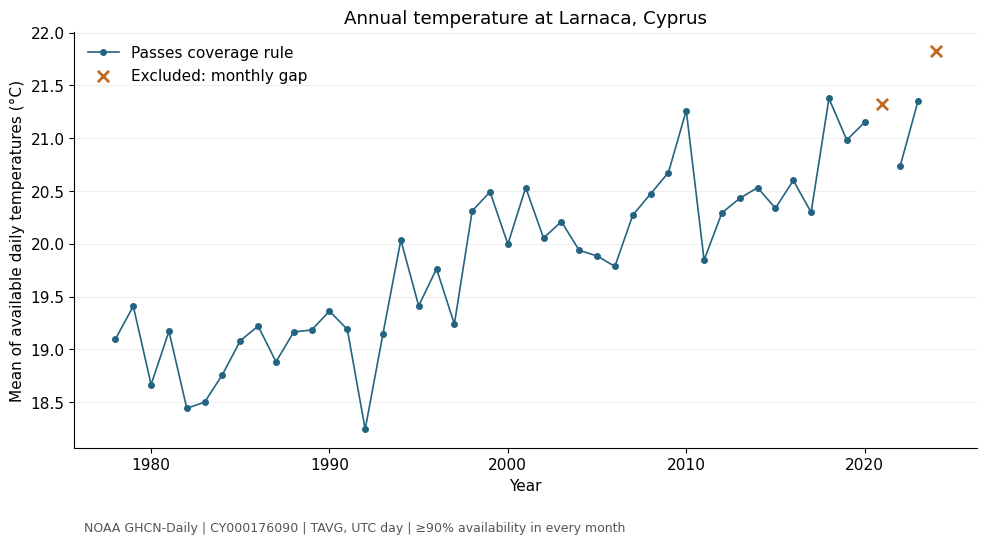

In [5]:
output_dir = Path("outputs/cyprus")
output_dir.mkdir(parents=True, exist_ok=True)
blue, orange, red = "#246482", "#c16a22", "#a33943"
plt.rcParams.update({"font.size": 11, "axes.spines.top": False,
                     "axes.spines.right": False, "figure.facecolor": "white"})

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(annual.index, annual.temp_c.where(annual.included),
        color=blue, lw=1.2, marker="o", ms=4, label="Passes coverage rule")
ax.scatter(annual.index[~annual.included], annual.loc[~annual.included, "temp_c"],
           color=orange, marker="x", s=65, linewidth=2, label="Excluded: monthly gap")
ax.set(title="Annual temperature at Larnaca, Cyprus", xlabel="Year",
       ylabel="Mean of available daily temperatures (°C)")
ax.grid(axis="y", alpha=0.2)
ax.legend(frameon=False, loc="upper left")
fig.text(0.09, 0.02, "NOAA GHCN-Daily | CY000176090 | TAVG, UTC day | ≥90% availability in every month", fontsize=9, color="#555555")
fig.tight_layout(rect=(0, 0.06, 1, 1))
fig.savefig(output_dir / "annual-temperature.png", dpi=180)
plt.show()

In [6]:
import hvplot

plot_data = annual.reset_index()
plot_data["min_month_pct"] = 100 * plot_data.min_month_coverage
plot_data["line_c"] = plot_data.temp_c.where(plot_data.included)
hover_columns = ["valid_days", "coverage_pct", "min_month_pct"]
line = plot_data.hvplot.line(x="year", y="line_c", color=blue, line_width=1)
points = plot_data.loc[plot_data.included].hvplot.scatter(
    x="year", y="temp_c", color=blue, size=45,
    hover_cols=hover_columns, label="Passes coverage rule")
excluded = plot_data.loc[~plot_data.included].hvplot.scatter(
    x="year", y="temp_c", color=orange, marker="x", size=90,
    hover_cols=hover_columns, label="Excluded: monthly gap")
interactive = (line * points * excluded).opts(
    title="Larnaca annual temperature | NOAA CY000176090",
    xlabel="Year", ylabel="Annual mean temperature (°C)",
    width=900, height=440, legend_position="top_left", tools=["hover"])
hvplot.save(interactive, str(output_dir / "annual-temperature.html"), resources="inline")
interactive

:Overlay
   .Curve.I                            :Curve   [year]   (line_c)
   .Scatter.Passes_coverage_rule       :Scatter   [year]   (temp_c,valid_days,coverage_pct,min_month_pct)
   .Scatter.Excluded_colon_monthly_gap :Scatter   [year]   (temp_c,valid_days,coverage_pct,min_month_pct)